# Import & Config

In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## Load

In [2]:
train_path = "../data/raw/train.csv"
test_path = "../data/raw/test.csv"

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

In [3]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (891, 12)
Test shape: (418, 11)


In [4]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


# train dataset shcema

In [6]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


## statistik

In [7]:
train.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


In [10]:
for col in train.columns:
    print(
        f"{col:15} "
        f"unique = {train[col].nunique():4} \t"
        f"dtype = {train[col].dtype}"
    )

PassengerId     unique =  891 	dtype = int64
Survived        unique =    2 	dtype = int64
Pclass          unique =    3 	dtype = int64
Name            unique =  891 	dtype = str
Sex             unique =    2 	dtype = str
Age             unique =   88 	dtype = float64
SibSp           unique =    7 	dtype = int64
Parch           unique =    7 	dtype = int64
Ticket          unique =  681 	dtype = str
Fare            unique =  248 	dtype = float64
Cabin           unique =  147 	dtype = str
Embarked        unique =    3 	dtype = str


## dictionary list

In [16]:
data_dictionary = pd.DataFrame({
    "column": [
        "PassengerId",
        "Survived",
        "Pclass",
        "Name",
        "Sex",
        "Age",
        "SibSp",
        "Parch",
        "Ticket",
        "Fare",
        "Cabin",
        "Embarked"
    ],
    
    "description": [
        "Unique passenger identifier",
        "Survival target",
        "Passenger ticket class",
        "Passenger name",
        "Passenger sex",
        "Passenger age",
        "Number of siblings/spouses aboard",
        "Number of parents/children aboard",
        "Ticket number",
        "Passenger fare",
        "Cabin number",
        "Port of embarkation"
    ],
    
    "role": [
        "identifier",
        "target",
        "feature",
        "feature",
        "feature",
        "feature",
        "feature",
        "feature",
        "feature",
        "feature",
        "feature",
        "feature"
    ], 

    "description": [
        "", 
        "0 = No, 1 = Yes", 
        "1 = 1st, 2 = 2nd, 3 = 3rd", 
        "",
        "",
        "",
        "",
        "",
        "",
        "",
        "",
        "C = Cherbourg, Q = Queenstown, S = Southampton",
    ]
})

data_dictionary

,column,description,role
0,PassengerId,,identifier
1,Survived,"0 = No, 1 = Yes",target
2,Pclass,"1 = 1st, 2 = 2nd, 3 = 3rd",feature
3,Name,,feature
4,Sex,,feature
5,Age,,feature
6,SibSp,,feature
7,Parch,,feature
8,Ticket,,feature
9,Fare,,feature


Variable Notes
pclass: A proxy for socio-economic status (SES)
1st = Upper
2nd = Middle
3rd = Lower

age: Age is fractional if less than 1. If the age is estimated, is it in the form of xx.5

sibsp: The dataset defines family relations in this way...
Sibling = brother, sister, stepbrother, stepsister
Spouse = husband, wife (mistresses and fiancés were ignored)

parch: The dataset defines family relations in this way...
Parent = mother, father
Child = daughter, son, stepdaughter, stepson
Some children travelled only with a nanny, therefore parch=0 for them.

## Data Quality Assessment

### Missing Value

In [ ]:
missing = (
    train.isna()
    .sum()
    .to_frame("missing_count")
)

missing["missing_pct"] = (
    missing["missing_count"] / len(train) * 100
)

missing = missing.sort_values(
    "missing_pct",
    ascending=False
)

missing

,missing_count,missing_pct
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467
PassengerId,0,0.000000
Name,0,0.000000
Pclass,0,0.000000
Survived,0,0.000000
Sex,0,0.000000
Parch,0,0.000000
SibSp,0,0.000000


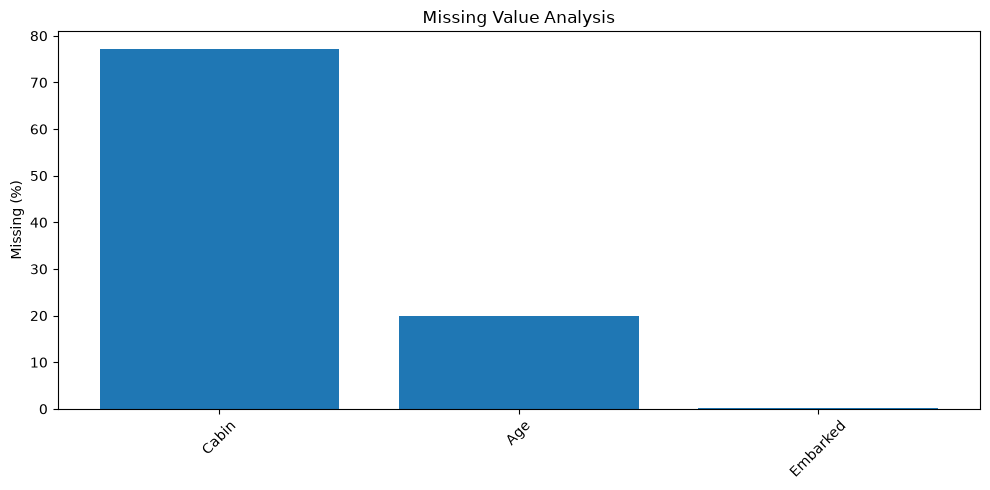

In [20]:
import matplotlib.pyplot as plt

missing_plot = missing[missing["missing_count"] > 0]

plt.figure(figsize=(10, 5))

plt.bar(
    missing_plot.index,
    missing_plot["missing_pct"]
)

plt.ylabel("Missing (%)")
plt.title("Missing Value Analysis")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Duplicate & Data Integrity

### general duplicate

In [21]:
train.duplicated().sum()

np.int64(0)

### Passenger ID

In [22]:
train["PassengerId"].duplicated().sum()

np.int64(0)

In [24]:
test["PassengerId"].duplicated().sum()

np.int64(0)

In [25]:
train["Age"].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

In [26]:
train["Fare"].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

### Check categorical values:

In [27]:
print(train["Sex"].unique())
print(train["Embarked"].unique())
print(train["Pclass"].unique())

<StringArray>
['male', 'female']
Length: 2, dtype: str
<StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str
[3 1 2]


In [28]:
train["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [29]:
train["Survived"].value_counts(normalize=True) * 100

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

## Target Distribution

In [30]:
survival_rate = (
    train["Survived"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

survival_rate

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64

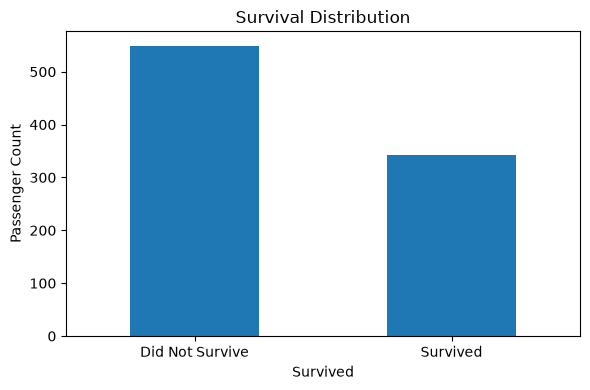

In [31]:
plt.figure(figsize=(6, 4))

train["Survived"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Passenger Count")

plt.xticks(
    ticks=[0, 1],
    labels=["Did Not Survive", "Survived"],
    rotation=0
)

plt.tight_layout()
plt.show()

# EDA

## Sex vs Survival

In [32]:
sex_survival = pd.crosstab(
    train["Sex"],
    train["Survived"],
    normalize="index"
) * 100

sex_survival

Survived,0,1
Sex,,
female,25.796178,74.203822
male,81.109185,18.890815


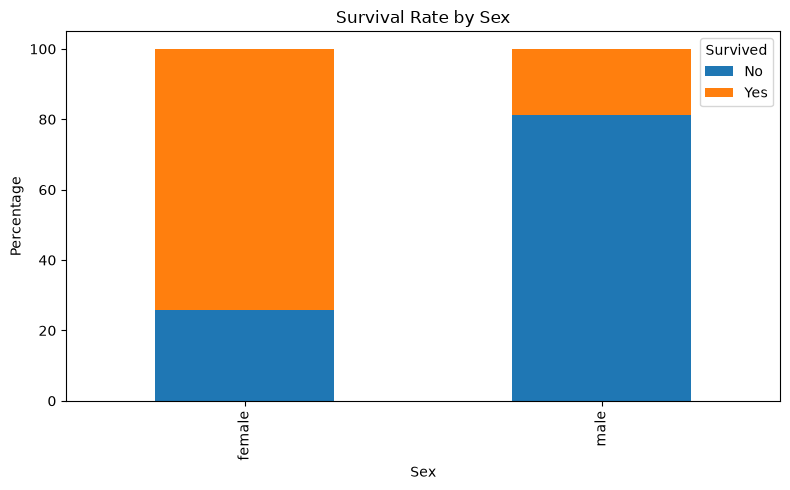

In [33]:
sex_survival.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Percentage")
plt.legend(
    title="Survived",
    labels=["No", "Yes"]
)

plt.tight_layout()
plt.show()

In [34]:
train.groupby("Sex")["Survived"].mean().sort_values(
    ascending=False
)

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

## Passenger Class

In [35]:
train.groupby("Pclass")["Survived"].agg(
    ["count", "mean"]
)

,count,mean
Pclass,,
1,216,0.629630
2,184,0.472826
3,491,0.242363


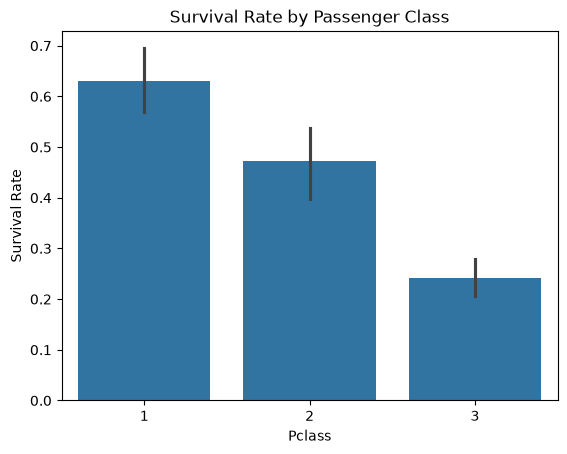

In [36]:
import seaborn as sns

sns.barplot(
    data=train,
    x="Pclass",
    y="Survived"
)

plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

## Age

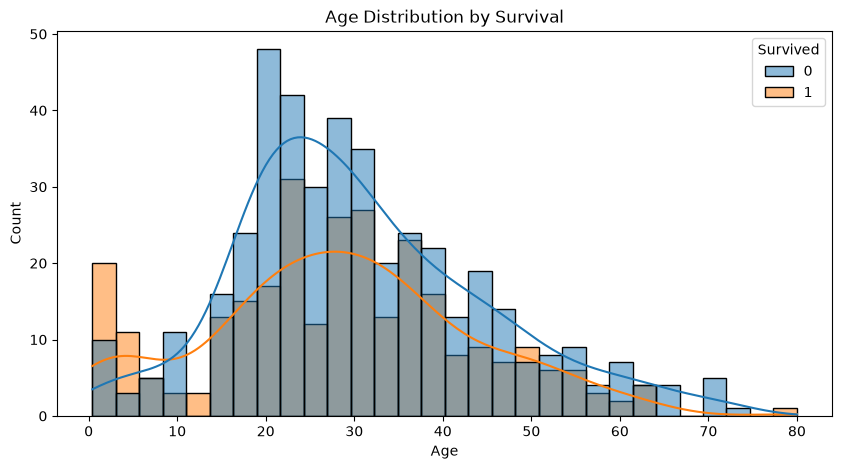

In [37]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=train,
    x="Age",
    hue="Survived",
    bins=30,
    kde=True
)

plt.title("Age Distribution by Survival")
plt.show()

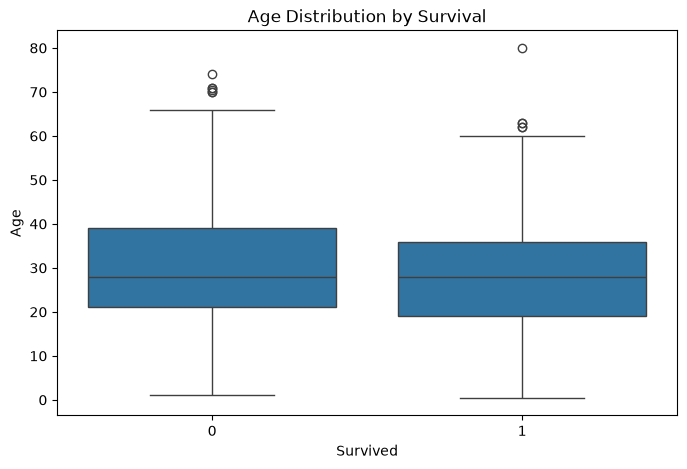

In [38]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=train,
    x="Survived",
    y="Age"
)

plt.title("Age Distribution by Survival")
plt.show()

## Family Structure

In [39]:
train["FamilySize"] = (
    train["SibSp"] +
    train["Parch"] +
    1
)

In [40]:
train.groupby("FamilySize")["Survived"].agg(
    ["count", "mean"]
)

,count,mean
FamilySize,,
1,537,0.303538
2,161,0.552795
3,102,0.578431
4,29,0.724138
5,15,0.200000
6,22,0.136364
7,12,0.333333
8,6,0.000000
11,7,0.000000


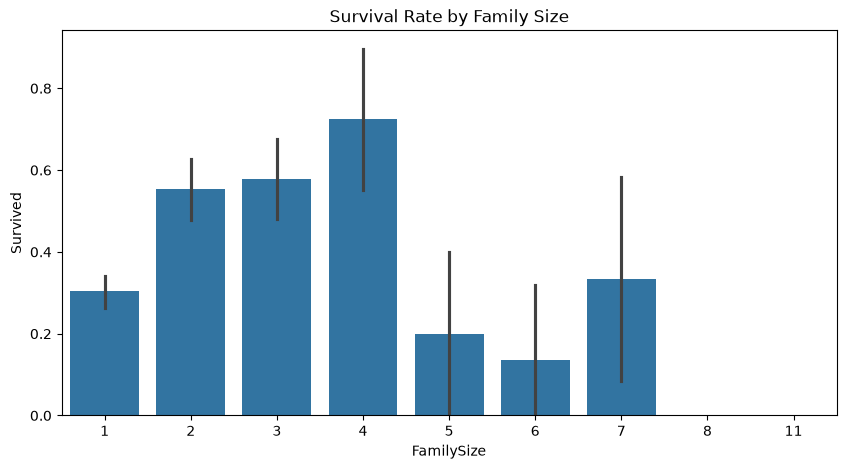

In [41]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=train,
    x="FamilySize",
    y="Survived"
)

plt.title("Survival Rate by Family Size")
plt.show()

## Interaction Analysis

In [42]:
sex_class = (
    train
    .groupby(["Sex", "Pclass"])["Survived"]
    .agg(["count", "mean"])
    .reset_index()
)

sex_class

,Sex,Pclass,count,mean
0,female,1,94,0.968085
1,female,2,76,0.921053
2,female,3,144,0.500000
3,male,1,122,0.368852
4,male,2,108,0.157407
5,male,3,347,0.135447


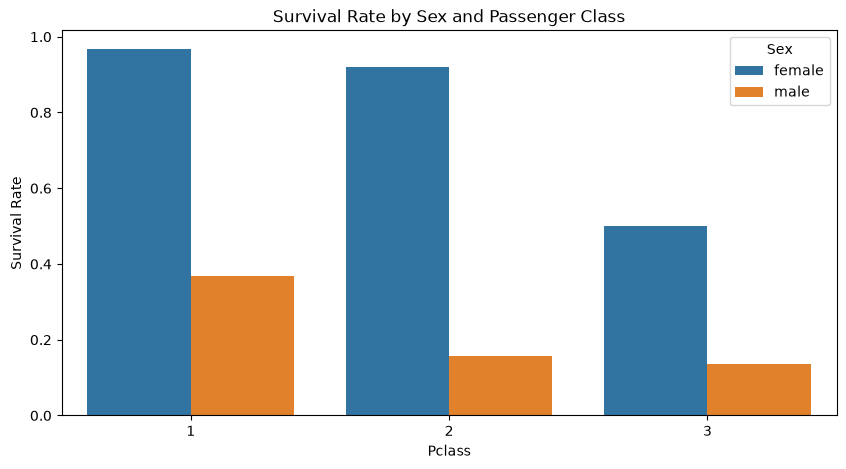

In [43]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=sex_class,
    x="Pclass",
    y="mean",
    hue="Sex"
)

plt.title("Survival Rate by Sex and Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

# Feature Engineering

## FamilySize

In [44]:
train["FamilySize"] = (
    train["SibSp"] +
    train["Parch"] +
    1
)

In [45]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1


In [46]:
train["IsAlone"] = (
    train["FamilySize"] == 1
).astype(int)

In [47]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,1


## Title

In [48]:
def extract_title(name):
    return (
        name
        .str.extract(r",\s*([^.]*)\.")[0]
        .str.strip()
    )

In [49]:
train["Title"] = extract_title(train["Name"])

In [51]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,IsAlone,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,0,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,0,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,1,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,0,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,1,Mr


In [52]:
train["Title"].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [53]:
common_titles = [
    "Mr",
    "Miss",
    "Mrs",
    "Master"
]

train["Title"] = train["Title"].where(
    train["Title"].isin(common_titles),
    "Rare"
)

## HasCabin

In [54]:
train["HasCabin"] = (
    train["Cabin"]
    .notna()
    .astype(int)
)

In [55]:
train["Deck"] = (
    train["Cabin"]
    .str[0]
)

In [56]:
train["Deck"] = train["Deck"].fillna("Unknown")

## Family Category

In [57]:
def family_category(size):
    if size == 1:
        return "Alone"
    elif size <= 4:
        return "Small"
    else:
        return "Large"

In [58]:
train["FamilyCategory"] = (
    train["FamilySize"]
    .apply(family_category)
)

# Train/Test Split

In [59]:
from sklearn.model_selection import train_test_split

X = train.drop(
    columns=["Survived"]
)

y = train["Survived"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Build Baseline

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline

feature_engineer = TitanicFeatureEngineer()

X_train_fe = feature_engineer.fit_transform(X_train)
X_valid_fe = feature_engineer.transform(X_valid)

preprocessor = build_preprocessor(X_train_fe)

baseline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            DummyClassifier(
                strategy="most_frequent"
            )
        )
    ]
)

baseline.fit(X_train, y_train)

## evaluation

In [ ]:
from sklearn.metrics import accuracy_score

baseline_pred = baseline.predict(X_valid)

print(
    "Baseline Accuracy:",
    accuracy_score(
        y_valid,
        baseline_pred
    )
)

# Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        (
            "features",
            TitanicFeatureEngineer()
        ),
        (
            "preprocessor",
            build_preprocessor(
                TitanicFeatureEngineer()
                .fit_transform(X_train)
            )
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

logistic_model.fit(
    X_train,
    y_train
)

pred = logistic_model.predict(X_valid)

accuracy_score(
    y_valid,
    pred
)

# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(
    steps=[
        (
            "features",
            TitanicFeatureEngineer()
        ),
        (
            "preprocessor",
            build_preprocessor(
                TitanicFeatureEngineer()
                .fit_transform(X_train)
            )
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=500,
                max_depth=8,
                min_samples_leaf=3,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(X_valid)

accuracy_score(
    y_valid,
    rf_pred
)

# Model Benchmarking

Senior portfolio sebaiknya tidak mengatakan:

"Saya memilih Random Forest."

Tanpa membandingkan model.

Kita buat beberapa model:

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.linear_model import LogisticRegression

## dictionary

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        max_depth=8,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

# Cross Validation

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [ ]:
results = []

for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            (
                "features",
                TitanicFeatureEngineer()
            ),
            (
                "preprocessor",
                build_preprocessor(
                    TitanicFeatureEngineer()
                    .fit_transform(X_train)
                )
            ),
            (
                "model",
                model
            )
        ]
    )

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=[
            "accuracy",
            "precision",
            "recall",
            "f1"
        ],
        n_jobs=-1
    )

    results.append({
        "model": name,
        "accuracy_mean": scores[
            "test_accuracy"
        ].mean(),

        "accuracy_std": scores[
            "test_accuracy"
        ].std(),

        "precision_mean": scores[
            "test_precision"
        ].mean(),

        "recall_mean": scores[
            "test_recall"
        ].mean(),

        "f1_mean": scores[
            "test_f1"
        ].mean()
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    "accuracy_mean",
    ascending=False
)

# Confusion Matrix

```bash
True Positive
True Negative
False Positive
False Negative
```

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

best_model = rf_model

best_model.fit(
    X_train,
    y_train
)

pred = best_model.predict(
    X_valid
)

cm = confusion_matrix(
    y_valid,
    pred
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Did Not Survive",
        "Survived"
    ]
).plot()

plt.title("Confusion Matrix")
plt.show()

# Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_valid,
        pred,
        target_names=[
            "Did Not Survive",
            "Survived"
        ]
    )
)

# Error Analysis

In [ ]:
validation_result = X_valid.copy()

validation_result["actual"] = y_valid
validation_result["predicted"] = pred

validation_result["error"] = (
    validation_result["actual"]
    != validation_result["predicted"]
)

## lihat error

In [ ]:
errors = validation_result[
    validation_result["error"]
]

errors.head()

In [ ]:
print(
    "Total validation samples:",
    len(validation_result)
)

print(
    "Total errors:",
    len(errors)
)

In [ ]:
errors.groupby(
    "Sex"
).size()

In [ ]:
errors.groupby(
    "Pclass"
).size()

In [ ]:
errors.groupby(
    "Pclass"
)["Age"]
.mean()

# Probability Prediction

In [ ]:
probability = best_model.predict_proba(
    X_valid
)[:, 1]

In [ ]:
validation_result["survival_probability"] = probability

In [ ]:
validation_result[
    [
        "Sex",
        "Pclass",
        "Age",
        "survival_probability",
        "actual",
        "predicted"
    ]
].head(20)

# Feature Importance

In [ ]:
model = best_model.named_steps["model"]

In [ ]:
preprocessor = best_model.named_steps[
    "preprocessor"
]

feature_names = (
    preprocessor
    .get_feature_names_out()
)

In [ ]:
importance = pd.DataFrame({
    "feature": feature_names,
    "importance": model.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

importance.head(20)

In [ ]:
top_features = importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="importance",
    y="feature"
)

plt.title("Top Feature Importance")
plt.tight_layout()
plt.show()

# Permutation Importance

In [ ]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    best_model,
    X_valid,
    y_valid,
    scoring="accuracy",
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

In [ ]:
permutation_df = pd.DataFrame({
    "feature": X_valid.columns,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std
})

permutation_df = permutation_df.sort_values(
    "importance_mean",
    ascending=False
)

permutation_df

# Hyperparameter Optimization

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
param_grid = {
    "model__n_estimators": [
        200,
        500,
        800
    ],

    "model__max_depth": [
        4,
        6,
        8,
        10,
        None
    ],

    "model__min_samples_split": [
        2,
        5,
        10
    ],

    "model__min_samples_leaf": [
        1,
        2,
        4
    ],

    "model__max_features": [
        "sqrt",
        "log2"
    ]
}

In [ ]:
search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_grid,
    n_iter=30,
    scoring="accuracy",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)

In [ ]:
search.fit(
    X_train,
    y_train
)

In [ ]:
search.best_params_

In [ ]:
search.best_score_

# Final Model

In [ ]:
final_model = search.best_estimator_

In [ ]:
final_pred = final_model.predict(
    X_valid
)

final_probability = (
    final_model
    .predict_proba(X_valid)[:, 1]
)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

final_metrics = {
    "accuracy": accuracy_score(
        y_valid,
        final_pred
    ),

    "precision": precision_score(
        y_valid,
        final_pred
    ),

    "recall": recall_score(
        y_valid,
        final_pred
    ),

    "f1": f1_score(
        y_valid,
        final_pred
    )
}

final_metrics